# Project 3
## Case study: Red sea

**Connection to the GCP:**

First, we have to connect to the Google Cloud Platform. using the following command. Enter the login "bigdataocean2020@gmail.com" and password "bdoimt2023". Do it only once. We will maybe need an authentication: contact me at pierre.tandeo@imt-atlantique.fr.

In [ ]:
import os
os.environ['USE_AUTH_EPHEM'] = '0'

from google.colab import auth
auth.authenticate_user()

Imports :

In [ ]:
!pip install cartopy
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
import numpy as np
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature

#Generic Functions for 3D Visualization
The following functions are used to visualize clusters:

In [ ]:
# Création d'une fonction pour la visualisation des clusters GMM
def visualize_clusters_with_gmm(reduced_features, clusters, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(
        reduced_features[:, 0], reduced_features[:, 1], c=clusters, cmap='viridis', s=50
    )
    plt.title(f'Clustering des années avec GMM - {title}')
    plt.xlabel('Composante 1')
    plt.ylabel('Composante 2')
    plt.colorbar(label='Cluster')
    plt.show()

# Fonction pour visualiser les clusters en 3D avec Plotly
def visualize_clusters_interactive_3d(reduced_features, clusters, title, table):
    # Création d'un DataFrame pour simplifier la manipulation
    df = pd.DataFrame(reduced_features, columns=['Composante 1', 'Composante 2', 'Composante 3'])
    df['Cluster'] = clusters
    df['Year'] = table['Year']

    # graphe 3D interactif avec Plotly
    fig = px.scatter_3d(
        df,
        x='Composante 1',
        y='Composante 2',
        z='Composante 3',
        color='Cluster',
        hover_name='Year',
        title=f'Clustering interactif des années - {title}',
        labels={'Cluster': 'Cluster'}
    )

    fig.update_layout(
        scene=dict(
            xaxis_title='Composante 1',
            yaxis_title='Composante 2',
            zaxis_title='Composante 3'
        ),
        legend_title="Clusters"
    )
    fig.show()

#Overview

This section fetches and processes the primary data from the Red Sea dataset. It includes steps for visualizing distributions, seasonal cycles, and trends.

In [ ]:
%%bigquery output --project alert-ground-261008
SELECT
  year,
  month,
  day,
  sst,
  ssh,
  lon,
  lat,
FROM
  `bdo2020.bdo2020.1998_2015_withtimes`
WHERE
  lon BETWEEN 32 AND 45
  AND lat BETWEEN 13 AND 30

Query is running:   0%|          |

Downloading:   0%|          |

#SSH Histogram

Let’s begin by visualizing the distribution of Sea Surface Height (SSH) and Sea Surface Temperature (SST) across the dataset.

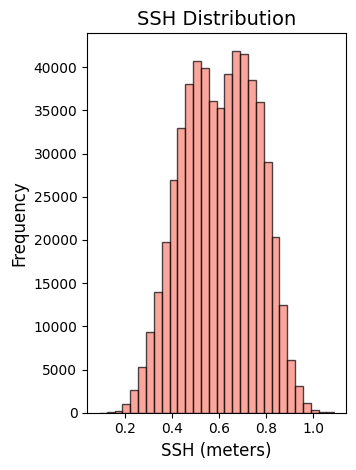

In [ ]:
# Histogram for SSH
plt.subplot(1, 2, 2)  # Second subplot
plt.hist(output['ssh'], bins=30, color='salmon', edgecolor='black', alpha=0.7)
plt.title('SSH Distribution', fontsize=14)
plt.xlabel('SSH (meters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Adjust layout and show
plt.tight_layout()
plt.show()

#SST Histogram

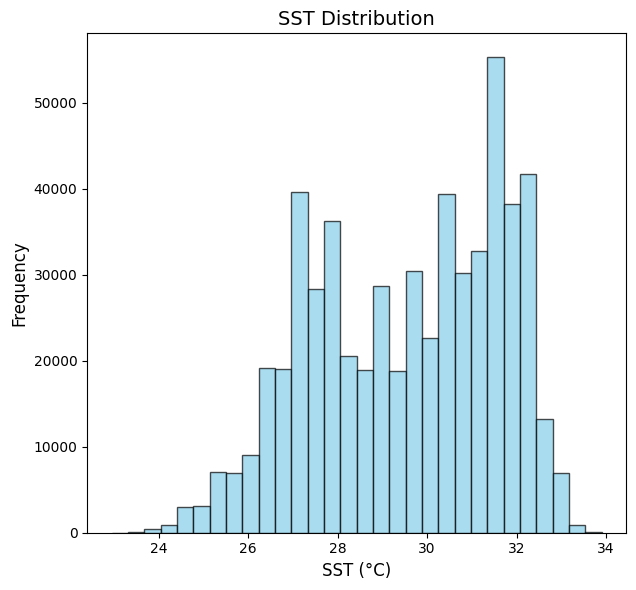

In [ ]:

plt.figure(figsize=(12, 6))

# Histogram for SST
plt.subplot(1, 2, 1)  # First subplot
plt.hist(output['sst'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('SST Distribution', fontsize=14)
plt.xlabel('SST (°C)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)


# Adjust layout and show
plt.tight_layout()
plt.show()

#Maps

Now, let’s explore the trends and spatial patterns using the maps.

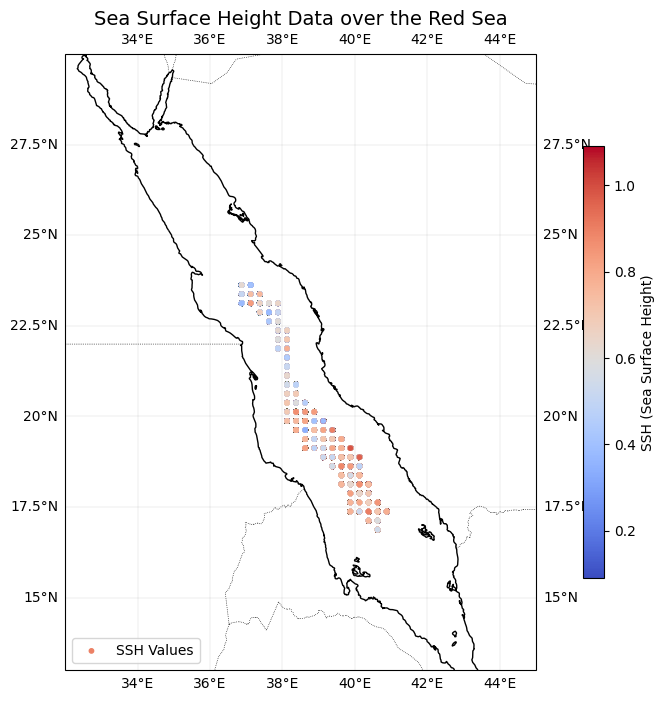

In [ ]:

# Créer la carte avec Cartopy
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Ajouter des limites des côtes et des frontières
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Limiter la région à afficher (zoom sur la mer Rouge)
ax.set_extent([32, 45, 13, 30], crs=ccrs.PlateCarree())  # [min_lon, max_lon, min_lat, max_lat]

# Ajouter des points des données
plt.scatter(
    output['lon'], output['lat'],
    c=output['ssh'], cmap='coolwarm',
    s=10, transform=ccrs.PlateCarree(), label='SSH Values', alpha=1
)

# Ajouter une barre de couleur pour les valeurs de SSH
plt.colorbar(label='SSH (Sea Surface Height)', shrink=0.7, orientation='vertical')

# Titre et légendes
plt.title('Sea Surface Height Data over the Red Sea', fontsize=14)
plt.legend(loc='lower left')
ax.gridlines(draw_labels=True, linewidth=0.2, color='gray', alpha=0.5)

# Afficher la carte
plt.show()

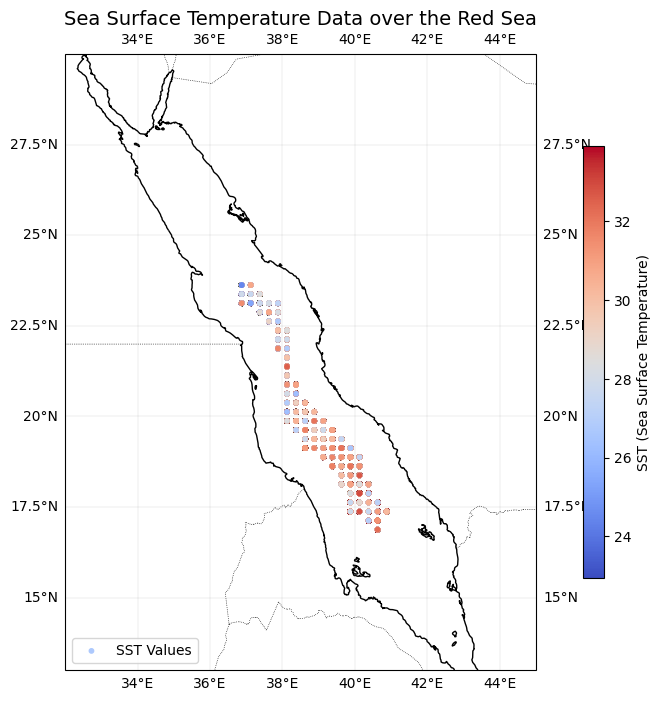

In [ ]:
# Créer la carte avec Cartopy
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Ajouter des limites des côtes et des frontières
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Limiter la région à afficher (zoom sur la mer Rouge)
ax.set_extent([32, 45, 13, 30], crs=ccrs.PlateCarree())  # [min_lon, max_lon, min_lat, max_lat]

# Ajouter des points des données avec SST
plt.scatter(
    output['lon'], output['lat'],
    c=output['sst'], cmap='coolwarm',  # Remplacer 'ssh' par 'sst'
    s=10, transform=ccrs.PlateCarree(), label='SST Values', alpha=1,
)

# Ajouter une barre de couleur pour les valeurs de SST
plt.colorbar(label='SST (Sea Surface Temperature)', shrink=0.7, orientation='vertical')

# Titre et légendes
plt.title('Sea Surface Temperature Data over the Red Sea', fontsize=14)  # Adapter le titre
plt.legend(loc='lower left')
ax.gridlines(draw_labels=True, linewidth=0.2, color='gray', alpha=0.5)

# Afficher la carte
plt.show()

#SST Mean Seasonal Cycle

Let’s start with an initial analysis of the seasonal cycles to understand how SST and SSH vary throughout the year.

    month        sst
0       1  27.208995
1       2  26.713834
2       3  26.980253
3       4  28.009144
4       5  29.542090
5       6  30.364441
6       7  31.127660
7       8  31.934980
8       9  31.883550
9      10  31.590425
10     11  30.416568
11     12  28.721020


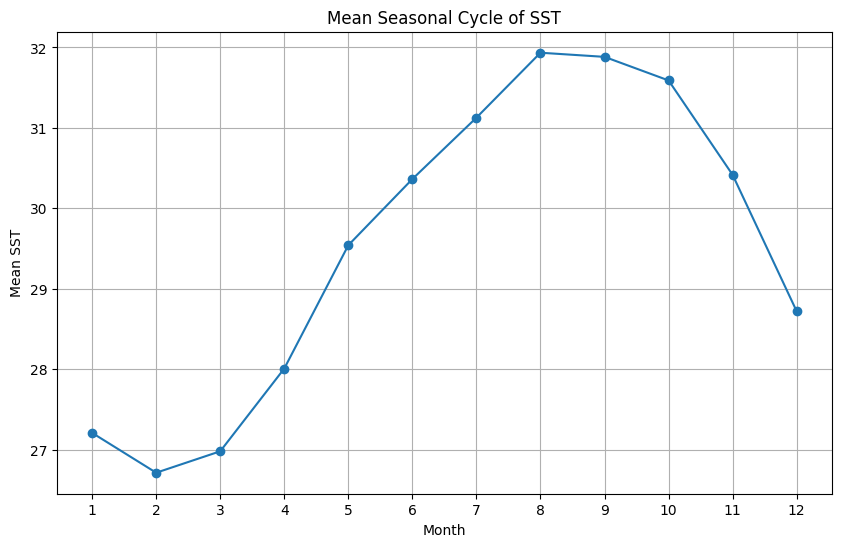

In [ ]:
# Calculer la moyenne saisonnière (par mois)
mean_seasonal_cycle = output.groupby('month')['sst'].mean()

# Réinitialiser l'index pour faciliter l'accès
mean_seasonal_cycle = mean_seasonal_cycle.reset_index()

# Affichage des résultats
print(mean_seasonal_cycle)

# Tracer le cycle saisonnier
plt.figure(figsize=(10, 6))
plt.plot(mean_seasonal_cycle['month'], mean_seasonal_cycle['sst'], marker='o')
plt.title('Mean Seasonal Cycle of SST')
plt.xlabel('Month')
plt.ylabel('Mean SST')
plt.xticks(range(1, 13))  # Mois de 1 à 12
plt.grid(True)
plt.show()

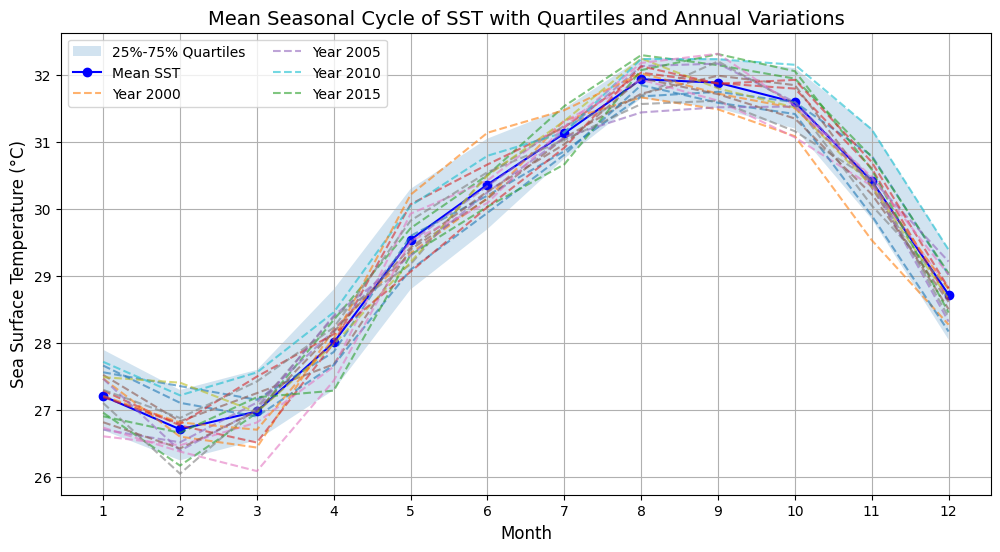

In [ ]:
# Assurons-nous que les données contiennent 'year', 'month', et 'sst'
# Grouper par mois pour calculer les statistiques de SST
seasonal_stats = output.groupby('month')['sst'].agg(['mean', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]).reset_index()
seasonal_stats.rename(columns={'mean': 'mean', '<lambda_0>': 'q25', '<lambda_1>': 'q75'}, inplace=True)

# Tracer la moyenne saisonnière avec les quartiles
plt.figure(figsize=(12, 6))
plt.fill_between(
    seasonal_stats['month'], seasonal_stats['q25'], seasonal_stats['q75'], alpha=0.2, label='25%-75% Quartiles'
)
plt.plot(seasonal_stats['month'], seasonal_stats['mean'], marker='o', color='blue', label='Mean SST')

# Superposer les cycles annuels individuels
for year in output['year'].unique():
    yearly_data = output[output['year'] == year].groupby('month')['sst'].mean()
    plt.plot(yearly_data.index, yearly_data.values, linestyle='--', alpha=0.6, label=f'Year {year}' if year % 5 == 0 else "")

# Configuration du graphique
plt.title('Mean Seasonal Cycle of SST with Quartiles and Annual Variations', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sea Surface Temperature (°C)', fontsize=12)
plt.xticks(range(1, 13))
plt.legend(loc='best', fontsize=10, ncol=2)
plt.grid(True)
plt.show()

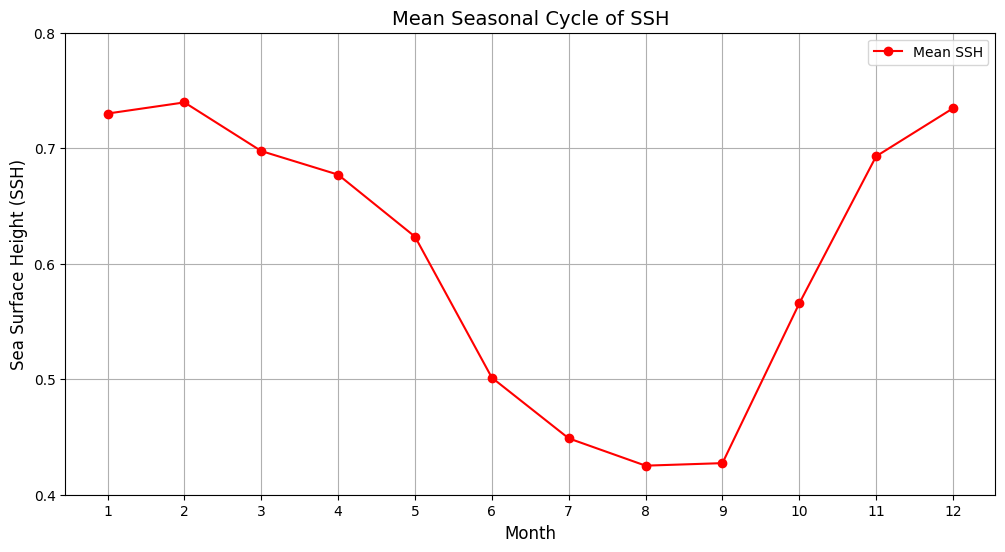

In [ ]:
# Calculer la moyenne saisonnière (par mois) pour SSH
mean_seasonal_cycle_ssh = output.groupby('month')['ssh'].mean().reset_index()

# Tracer la moyenne saisonnière de SSH
plt.figure(figsize=(12, 6))
plt.plot(mean_seasonal_cycle_ssh['month'], mean_seasonal_cycle_ssh['ssh'], marker='o', color='red', label='Mean SSH')

# Configuration des axes, du titre et des limites
plt.title('Mean Seasonal Cycle of SSH', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sea Surface Height (SSH)', fontsize=12)
plt.xticks(range(1, 13))  # Mois de 1 à 12
plt.yticks([0.4, 0.5, 0.6, 0.7, 0.8])  # Échelle spécifique pour SSH
plt.ylim(0.4, 0.8)  # Limites de l'axe Y
plt.legend(loc='best', fontsize=10)
plt.grid(True)
plt.show()

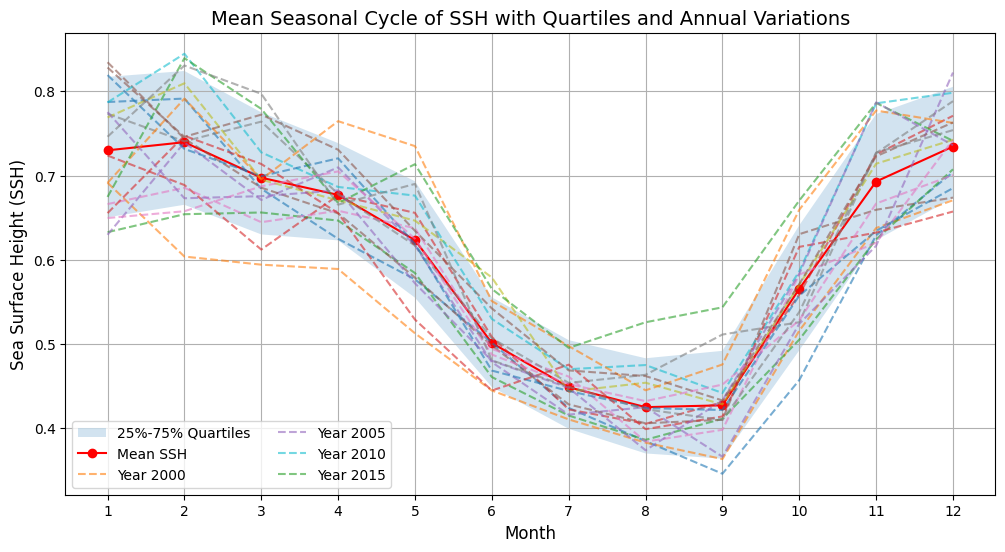

In [ ]:
# Grouper par mois pour calculer les statistiques de SSH
seasonal_stats_ssh = output.groupby('month')['ssh'].agg(['mean', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]).reset_index()
seasonal_stats_ssh.rename(columns={'mean': 'mean', '<lambda_0>': 'q25', '<lambda_1>': 'q75'}, inplace=True)

# Tracer la moyenne saisonnière de SSH avec les quartiles
plt.figure(figsize=(12, 6))
plt.fill_between(
    seasonal_stats_ssh['month'], seasonal_stats_ssh['q25'], seasonal_stats_ssh['q75'], alpha=0.2, label='25%-75% Quartiles'
)
plt.plot(seasonal_stats_ssh['month'], seasonal_stats_ssh['mean'], marker='o', color='red', label='Mean SSH')

# Superposer les cycles annuels individuels
for year in output['year'].unique():
    yearly_data_ssh = output[output['year'] == year].groupby('month')['ssh'].mean()
    plt.plot(yearly_data_ssh.index, yearly_data_ssh.values, linestyle='--', alpha=0.6, label=f'Year {year}' if year % 5 == 0 else "")

# Configuration du graphique
plt.title('Mean Seasonal Cycle of SSH with Quartiles and Annual Variations', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sea Surface Height (SSH)', fontsize=12)
plt.xticks(range(1, 13))
plt.legend(loc='best', fontsize=10, ncol=2)
plt.grid(True)
plt.show()

To refine our analysis of the outlier years, let’s focus on those that overrun the 25% and 75% quartile limits. A normal year should have around 50% of its values overrunning these limits.

Année avec le plus grand pourcentage de dépassements : 2015.0
Pourcentage de dépassements : 55.78649031648559


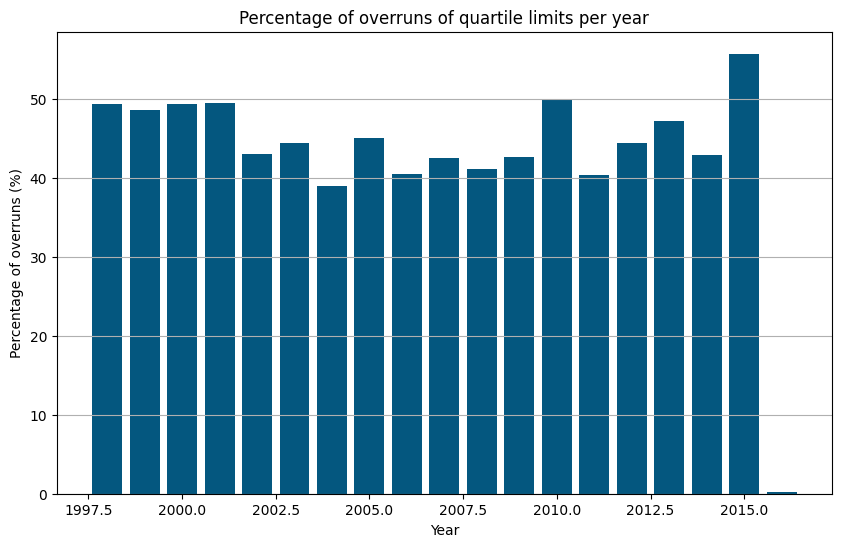

In [ ]:
# Calculate seasonal statistics for SST
seasonal_stats = output.groupby('month')['sst'].agg(['mean', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]).reset_index()
seasonal_stats.rename(columns={'mean': 'mean', '<lambda_0>': 'q25', '<lambda_1>': 'q75'}, inplace=True)

# Merge seasonal statistics with the original DataFrame
output = pd.merge(output, seasonal_stats[['month', 'q25', 'q75']], on='month', how='left')

# Now you can proceed with identifying out-of-bounds values
output['out_of_bounds'] = (output['sst'] < output['q25']) | (output['sst'] > output['q75'])


# Compter les valeurs hors limites pour chaque année
out_of_bounds_by_year = output.groupby('year')['out_of_bounds'].sum().reset_index()

# Normaliser en pourcentage (100% = 31755)
reference_value = 31755
out_of_bounds_by_year['out_of_bounds_percentage'] = (out_of_bounds_by_year['out_of_bounds'] / reference_value) * 100

# Identifier l'année avec le plus grand pourcentage de dépassements
outlier_year = out_of_bounds_by_year.loc[out_of_bounds_by_year['out_of_bounds_percentage'].idxmax()]

# Afficher les résultats
print("Année avec le plus grand pourcentage de dépassements :", outlier_year['year'])
print("Pourcentage de dépassements :", outlier_year['out_of_bounds_percentage'])

# Visualiser les dépassements par année en pourcentage
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(out_of_bounds_by_year['year'], out_of_bounds_by_year['out_of_bounds_percentage'], color='#04577f')
plt.title('Percentage of overruns of quartile limits per year')
plt.xlabel('Year')
plt.ylabel('Percentage of overruns (%)')
plt.grid(axis='y')
plt.show()

Année avec le plus grand pourcentage de dépassements : 2015.0
Pourcentage de dépassements : 64.10958904109589


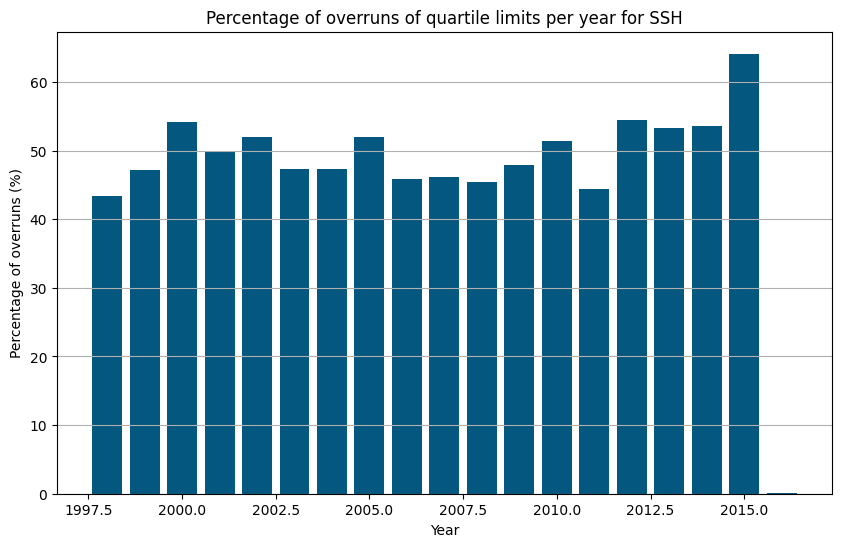

In [ ]:
# Now you can perform the merge
# Specifying suffixes to avoid conflicts
output = output.merge(seasonal_stats_ssh[['month', 'q25', 'q75']], on='month', how='left', suffixes=('', '_new'))

# Now, drop the original q25 and q75, and rename the new ones
output = output.drop(['q25', 'q75'], axis=1)
output = output.rename(columns={'q25_new': 'q25', 'q75_new': 'q75'})

# Identifier les valeurs de SSH hors limites
output['out_of_bounds'] = (output['ssh'] < output['q25']) | (output['ssh'] > output['q75'])  # Changed 'sst' to 'ssh'

# Compter les valeurs hors limites pour chaque année
out_of_bounds_by_year = output.groupby('year')['out_of_bounds'].sum().reset_index()

# Normaliser en pourcentage (adapt the reference value if needed)
reference_value = 31755
out_of_bounds_by_year['out_of_bounds_percentage'] = (out_of_bounds_by_year['out_of_bounds'] / reference_value) * 100

# Identifier l'année avec le plus grand pourcentage de dépassements
outlier_year = out_of_bounds_by_year.loc[out_of_bounds_by_year['out_of_bounds_percentage'].idxmax()]

# Afficher les résultats
print("Année avec le plus grand pourcentage de dépassements :", outlier_year['year'])
print("Pourcentage de dépassements :", outlier_year['out_of_bounds_percentage'])

# Visualiser les dépassements par année en pourcentage
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(out_of_bounds_by_year['year'], out_of_bounds_by_year['out_of_bounds_percentage'], color='#04577f')
plt.title('Percentage of overruns of quartile limits per year for SSH')  # Changed title
plt.xlabel('Year')
plt.ylabel('Percentage of overruns (%)')
plt.grid(axis='y')
plt.show()

In [ ]:
print(seasonal_stats_ssh.head())


   month      mean     q25       q75
0      1  0.730023  0.6505  0.817200
1      2  0.739675  0.6654  0.824225
2      3  0.697557  0.6302  0.775100
3      4  0.677106  0.6231  0.738600
4      5  0.623418  0.5551  0.693300


Now, let’s plot the trends across the years to observe how the data evolves over time.

Trend: 5.13 cm per decade


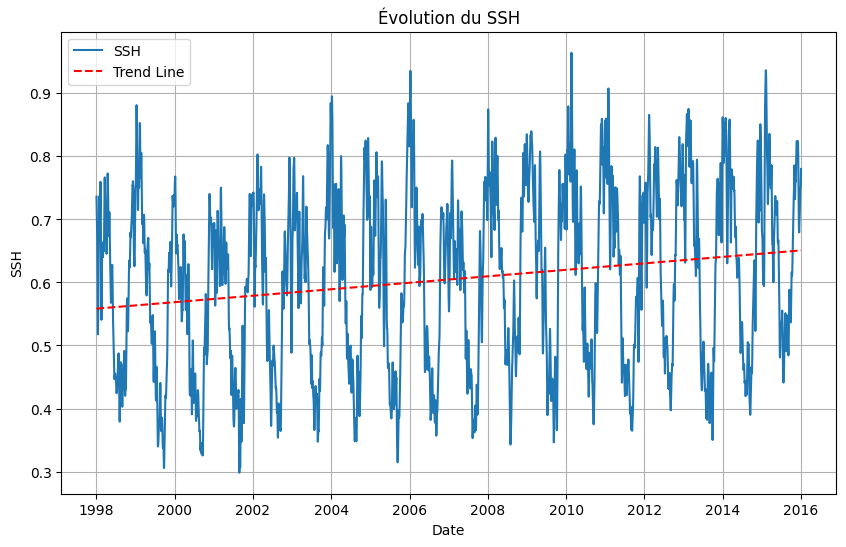

In [ ]:
# Assuming 'output' is your DataFrame containing the data
df_tendance = pd.DataFrame(output).groupby(['day', 'month', 'year'])[['sst', 'ssh']].mean().reset_index()
df_tendance["day_month_year"] = df_tendance['day'].astype(str) + "/" + df_tendance['month'].astype(str) + "/" + df_tendance['year'].astype(str)
df_tendance = df_tendance.sort_values(by=['year', 'month', 'day'], ascending=True)
df_tendance['day_month_year'] = pd.to_datetime(df_tendance['day_month_year'], format='%d/%m/%Y')

# Calculate trend line
x = df_tendance['day_month_year'].astype(np.int64) // 10**9  # Convert dates to numeric values for trend calculation
y = df_tendance['ssh']
z = np.polyfit(x, y, 1)  # Fit a 1st-degree polynomial (linear trend)
p = np.poly1d(z)  # Create a polynomial function

# Extract the slope from the polyfit result
slope = z[0]  # z[0] contains the slope of the fitted line

# Convert to cm/decade
cm_per_decade = slope * 100 * 31536000 * 10

print(f"Trend: {cm_per_decade:.2f} cm per decade")

# Now you can plot the data and the trend line
plt.figure(figsize=(10, 6))
plt.plot(df_tendance['day_month_year'], df_tendance['ssh'], label='SSH')  # Original SSH data
plt.plot(df_tendance['day_month_year'], p(x), "r--", label='Trend Line')  # Trend line in red dashed style
plt.title('Évolution du SSH')
plt.xlabel('Date')
plt.ylabel('SSH')
plt.grid(True)
plt.legend(loc='best')  # Add legend to distinguish data and trend line
plt.show()

**Part 1)**

Model the daily mean SSH time series in the Red Sea, between longitudes (+32,+45) and latitudes (+13,+30). We suggest to use a linear tendancy and a one-year seasonal cycle such that: $SSH(t)=\alpha_0 + \alpha_1 t + \alpha_2 sin(2\pi\omega t) + \alpha_3 cos(2\pi\omega t)$, with $\omega=\frac{1}{365.25}$.

#1. Creation of a Unique Column for Date.

In [ ]:
output["day_month_year"] = output['day'].astype(str) + "/" + output['month'].astype(str) + "/" + output['year'].astype(str)
output = output.sort_values(by=['year', 'month', 'day'], ascending=True)
print(output)

        year  month  day    sst     ssh     lon     lat  out_of_bounds  \
9772    1998      1    2  28.35  0.8211  40.625  17.125           True   
9975    1998      1    2  28.50  0.8206  40.375  17.125           True   
13565   1998      1    2  28.35  0.7785  39.625  18.125          False   
24786   1998      1    2  28.35  0.7862  39.875  18.125          False   
32600   1998      1    2  28.50  0.8170  40.375  18.125          False   
...      ...    ...  ...    ...     ...     ...     ...            ...   
539223  2016      1    1  25.50  0.6238  38.125  21.875           True   
548707  2016      1    1  25.50  0.6219  37.875  21.875           True   
557236  2016      1    1  25.95  0.6754  37.875  22.875          False   
559394  2016      1    1  25.50  0.6671  37.375  22.875          False   
565643  2016      1    1  25.65  0.6727  37.625  22.875          False   

           q25     q75 day_month_year  
9772    0.6505  0.8172       2/1/1998  
9975    0.6505  0.8172       2/

# Visualization of Seasonality for SST and SSH



Text(0, 0.5, 'SST Value')

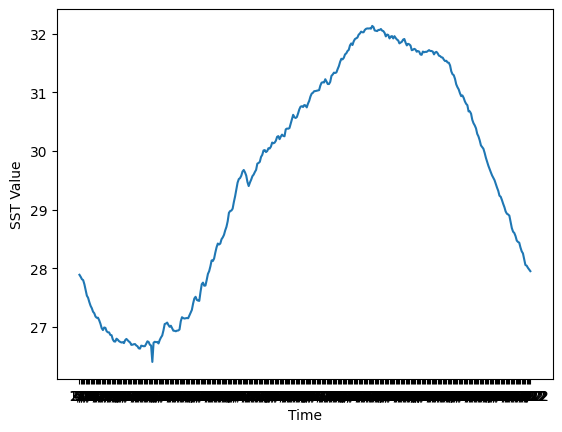

In [ ]:
seasonal = pd.DataFrame(output).groupby(['day', 'month'])['sst'].mean()
seasonal = seasonal.reset_index().sort_values(by=['month', 'day'], ascending=[True, True])
seasonal["day_month"] = seasonal['day'].astype(str) + "/" + seasonal['month'].astype(str)
plt.figure()
plt.plot(seasonal['day_month'], seasonal['sst'], label='SST (°C)')
plt.xlabel('Time')
plt.ylabel('SST Value')

Text(0, 0.5, 'SSH Value')

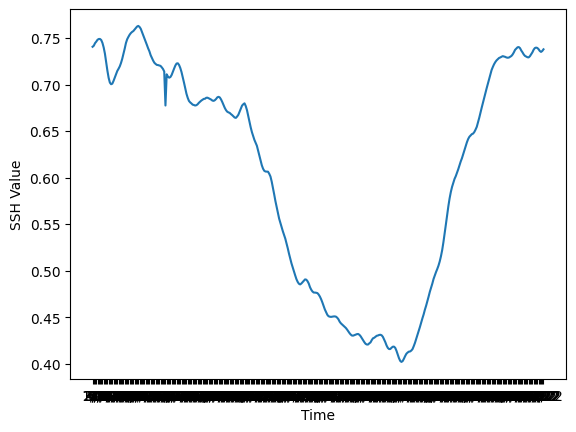

In [ ]:
seasonal = pd.DataFrame(output).groupby(['day', 'month'])['ssh'].mean()
seasonal = seasonal.reset_index().sort_values(by=['month', 'day'], ascending=[True, True])
seasonal["day_month"] = seasonal['day'].astype(str) + "/" + seasonal['month'].astype(str)
plt.figure()
plt.plot(seasonal['day_month'], seasonal['ssh'], label='SSH (m)')
plt.xlabel('Time')
plt.ylabel('SSH Value')

#Creating a DataFrame for Trend Analysis

In [ ]:
df_tendance = pd.DataFrame(output).groupby(['day', 'month', 'year'])[['sst', 'ssh']].mean().reset_index()
df_tendance["day_month_year"] = df_tendance['day'].astype(str) + "/" + df_tendance['month'].astype(str) + "/" + df_tendance['year'].astype(str)
df_tendance = df_tendance.sort_values(by=['year', 'month', 'day'], ascending=True)
df_tendance['day_month_year'] = pd.to_datetime(df_tendance['day_month_year'], format='%d/%m/%Y')

#Visualization of SST and SSH from 1998 to 2015

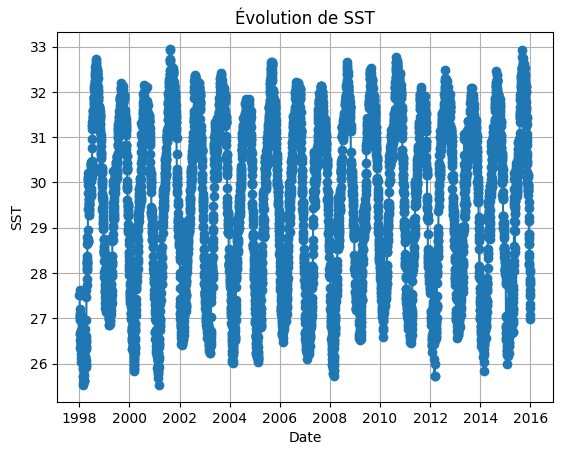

In [ ]:
plt.plot(df_tendance['day_month_year'], df_tendance['sst'], marker='o')
plt.title('Évolution de SST')
plt.xlabel('Date')
plt.ylabel('SST')
plt.grid(True)
plt.show()

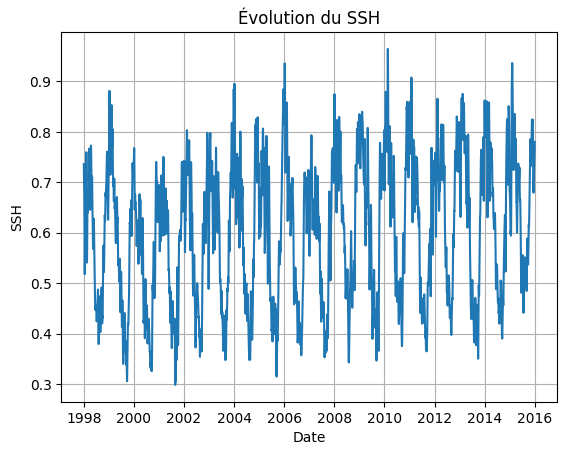

In [ ]:
plt.plot(df_tendance['day_month_year'], df_tendance['ssh'])
plt.title('Évolution du SSH')
plt.xlabel('Date')
plt.ylabel('SSH')
plt.grid(True)
plt.show()

# **Anti Correlation between SST and SSH**

Correlation between normalized SST and normalized SSH: -0.6839544127693893


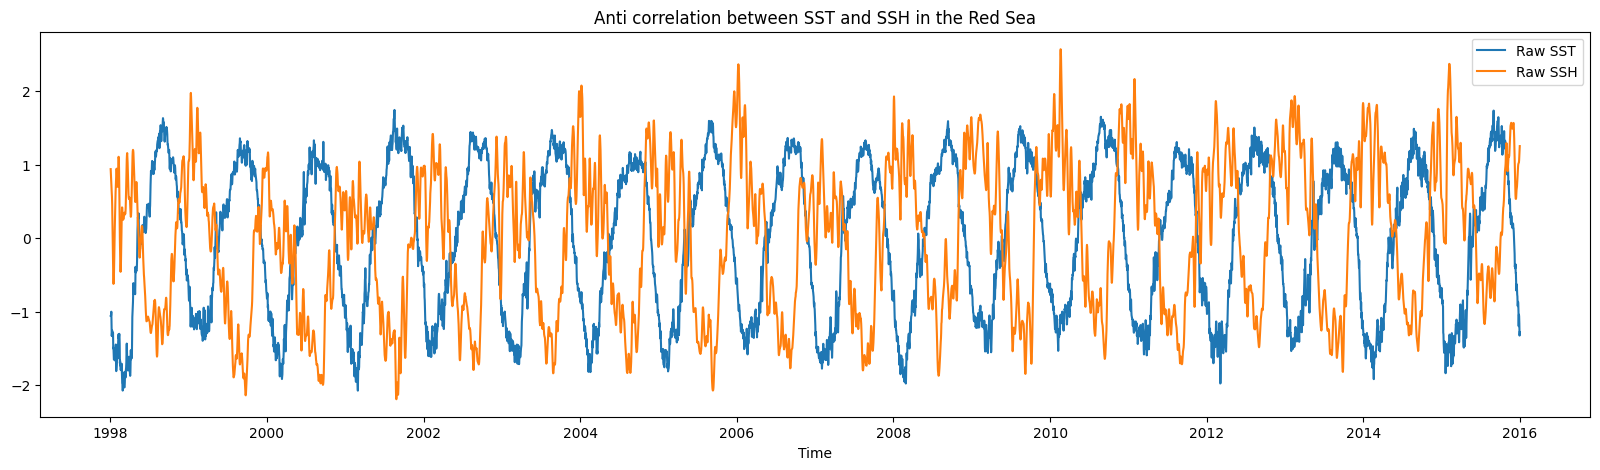

In [ ]:
normalized_sst = (df_tendance['sst'] - df_tendance['sst'].mean()) / df_tendance['sst'].std()
normalized_ssh = (df_tendance['ssh'] - df_tendance['ssh'].mean()) / df_tendance['ssh'].std()
correlation_sst_ssh = np.corrcoef(normalized_sst, normalized_ssh)[0, 1]
print(f"Correlation between normalized SST and normalized SSH: {correlation_sst_ssh}")

# Comparison of the model tendances
plt.figure(figsize=(20, 5))
plt.plot(df_tendance['day_month_year'], normalized_sst, label='Raw SST')
plt.plot(df_tendance['day_month_year'], normalized_ssh, label='Raw SSH')
plt.xlabel('Time')
plt.ylabel('')
plt.title('Anti correlation between SST and SSH in the Red Sea')
plt.legend()

#Creation of Two Pivot Tables for SST and SSH

In [ ]:
# Création des tables pivot pour sst et ssh
sst_table = (
    output[output["year"] != 2016].groupby(['year', 'month'])['sst']
    .mean()
    .unstack(level='month')  # Transforme les mois en colonnes
    .reset_index()           # Remet 'year' comme colonne
    .rename_axis(None, axis=1)  # Supprime les noms d'axes
)

ssh_table = (
    output[output["year"] != 2016].groupby(['year', 'month'])['ssh']
    .mean()
    .unstack(level='month')
    .reset_index()
    .rename_axis(None, axis=1)
)

# Ajout des noms de colonnes explicites pour chaque table
sst_table.columns = ['Year'] + [f'Month_{i}' for i in range(1, 13)]
ssh_table.columns = ['Year'] + [f'Month_{i}' for i in range(1, 13)]

# Remplir les valeurs manquantes par NaN
sst_table.fillna(value=pd.NA, inplace=True)
ssh_table.fillna(value=pd.NA, inplace=True)

# Affichage pour vérifier
print("Table des moyennes SST :")
print(sst_table)

print("\nTable des moyennes SSH :")
print(ssh_table)

Table des moyennes SST :
    Year    Month_1    Month_2    Month_3    Month_4    Month_5    Month_6  \
0   1998  26.738736  26.381466  26.090545  27.438966  29.520356  30.090230   
1   1999  27.564238  27.358374  27.154561  27.866782  29.598498  30.200230   
2   2000  27.470078  26.604043  26.441713  28.204195  29.341379  30.159598   
3   2001  26.960790  26.172106  26.958398  28.345747  29.713014  30.506437   
4   2002  27.193437  26.794766  27.500111  28.132356  29.064461  30.029828   
5   2003  27.290100  26.770690  26.516352  27.998391  30.070634  30.663448   
6   2004  27.468020  26.395363  27.007341  28.410632  29.304116  30.249023   
7   2005  26.709789  26.519643  27.112959  28.184138  29.510901  30.342299   
8   2006  27.525083  26.833559  27.253560  27.683218  29.396774  30.155172   
9   2007  26.609066  26.476047  26.815795  27.647701  29.929644  30.424540   
10  2008  27.105172  26.051308  27.044383  28.388161  29.175083  30.519483   
11  2009  27.491713  27.409113  26.9687

In [ ]:
# Préparation des données
sst_features = sst_table.drop(columns=['Year']).fillna(0)  # Supprimer la colonne 'Year' et gérer les NaN
ssh_features = ssh_table.drop(columns=['Year']).fillna(0)

# Normalisation des données pour le PCA
scaler = StandardScaler()
sst_features_scaled = scaler.fit_transform(sst_features)
ssh_features_scaled = scaler.fit_transform(ssh_features)

# Creating a Function to Determine the Optimal Number of Components for PCA

In [ ]:
# Fonction pour trouver le bon nombre de composantes
def find_optimal_pca_components(features, threshold=0.90):
    pca = PCA()
    pca.fit(features)

    # Variance expliquée cumulée
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    # Trouver le nombre de composantes pour atteindre le seuil
    optimal_components = np.argmax(cumulative_variance >= threshold) + 1

    # Courbe de la variance expliquée cumulée
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
    plt.axvline(optimal_components, color='r', linestyle='--', label=f'Optimal: {optimal_components} composants')
    plt.title('Variance expliquée cumulée par le PCA')
    plt.xlabel('Nombre de composantes')
    plt.ylabel('Variance expliquée cumulée')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    print(f"Nombre optimal de composantes pour atteindre {threshold:.0%} de la variance : {optimal_components}")
    return optimal_components

# Utilisation de la fonction sur le SST et le SSH
optimal_sst_components = find_optimal_pca_components(sst_features_scaled, threshold=0.75)
optimal_ssh_components = find_optimal_pca_components(ssh_features_scaled, threshold=0.75)

We Can Now Reduce the Dimensionality

In [ ]:
# Réduction de dimension avec PCA
def perform_pca(features, n_components=4):
    pca = PCA(n_components=n_components)
    reduced_features = pca.fit_transform(features)
    explained_variance = pca.explained_variance_ratio_
    components = pd.DataFrame(
        pca.components_,
        columns=sst_features.columns,
        index=[f"Composante {i+1}" for i in range(n_components)]
    )
    return reduced_features, explained_variance, components

# Appliquer le PCA pour le SST et le SSH
sst_reduced, sst_variance, sst_components = perform_pca(sst_features_scaled, 4)
ssh_reduced, ssh_variance, ssh_components = perform_pca(ssh_features_scaled, 4)

# Afficher les contributions des mois
print("Contributions des mois pour SST :")
print(sst_components)
print("\nVariance expliquée pour SST :", sst_variance)
# idem pour le SSH
print("\nContributions des mois pour SSH :")
print(ssh_components)
print("\nVariance expliquée pour SSH :", ssh_variance)

#Creating a Function to Display Component Details

This function provides a detailed breakdown of how the original features contribute to each principal component. It helps in interpreting the PCA results and understanding the importance of features in each component.

In [ ]:
# Affichage détaillé des contributions des mois pour chaque composante
def print_composantes_details(components, title):
    print(f"\nContributions des mois pour {title} :")
    for idx, row in components.iterrows():
        print(f"\n{idx} :")
        for month, value in row.items():
            print(f"  {month}: {value:.4f}")

# Affichage pour le SST
print_composantes_details(sst_components, "SST")

# Idem pour le SSH
print_composantes_details(ssh_components, "SSH")

# Gaussian Mixture pour le clustering

We also tested KMeans, but its results were less satisfactory, so we opted to use GMM (Gaussian Mixture Model).

First, we need to determine the optimal number of clusters. To achieve this, we will use the BIC (Bayesian Information Criterion) method.

In [ ]:
# Appliquer le PCA
sst_reduced, sst_variance, sst_components = perform_pca(sst_features_scaled, 8)
ssh_reduced, ssh_variance, ssh_components = perform_pca(ssh_features_scaled, 8)

def plot_bic_curve(features, max_clusters=10, title=''):
    """
    Trace la courbe des scores BIC pour des nombres de clusters différents.

    :param features: Données d'entrée réduites (PCA ou originales)
    :param max_clusters: Nombre maximum de clusters à tester
    :param title: Titre du graphique
    """
    bic_scores = []
    n_clusters_range = range(1, max_clusters + 1)

    # Ajustement du modèle pour différents nombres de clusters
    for n_clusters in n_clusters_range:
        gmm = GaussianMixture(n_components=n_clusters, random_state=42)
        gmm.fit(features)
        bic_scores.append(gmm.bic(features))

    # Tracer la courbe des scores BIC
    plt.figure(figsize=(8, 6))
    plt.plot(n_clusters_range, bic_scores, marker='o')
    plt.xlabel('Nombre de clusters')
    plt.ylabel('BIC Score')
    plt.title(f'Courbe BIC - {title}')
    plt.grid(True)
    plt.show()

    # Retourner les scores pour analyse ultérieure si nécessaire
    return bic_scores

# Appliquer pour SST et SSH
sst_bic_scores = plot_bic_curve(sst_reduced, max_clusters=10, title='SST')
ssh_bic_scores = plot_bic_curve(ssh_reduced, max_clusters=10, title='SSH')

We observe that the optimal number of clusters for SSH, for instance, is 5, as having 8 clusters does not provide additional meaningful insights for our years. Therefore, we will use this value in our model.

In [ ]:
# Appliquer le PCA
sst_reduced, sst_variance, sst_components = perform_pca(sst_features_scaled, 4)
ssh_reduced, ssh_variance, ssh_components = perform_pca(ssh_features_scaled, 4)

# Fonction pour le clustering avec GMM après avoir fait notre PCA
def gmm_clustering(reduced_features, n_components, title):
    gmm = GaussianMixture(n_components=n_components, random_state=42) # seed imposée pour reproduire les résultats
    clusters = gmm.fit_predict(reduced_features)
    return clusters, gmm

# Utilisation de la fonction
sst_clusters_gmm, sst_gmm_model = gmm_clustering(sst_reduced, n_components=2, title="SST")
ssh_clusters_gmm, ssh_gmm_model = gmm_clustering(ssh_reduced, n_components=5, title="SSH")

# Ajout des résultats des clusters GMM aux tables
sst_table['Cluster_GMM'] = sst_clusters_gmm
ssh_table['Cluster_GMM'] = ssh_clusters_gmm

# Visualiser les clusters GMM
visualize_clusters_with_gmm(sst_reduced, sst_clusters_gmm, 'SST')
visualize_clusters_with_gmm(ssh_reduced, ssh_clusters_gmm, 'SSH')

In [ ]:
from sklearn.metrics import silhouette_score

# Fonction pour calculer et afficher le score silhouette
def calculate_silhouette_score(reduced_features, clusters, title):
    score = silhouette_score(reduced_features, clusters)
    print(f"Silhouette Score for {title}: {score:.4f}")
    return score

In [ ]:
# Calcul du score silhouette pour SST
sst_silhouette_score = calculate_silhouette_score(sst_reduced, sst_clusters_gmm, "SST")

# Calcul du score silhouette pour SSH
ssh_silhouette_score = calculate_silhouette_score(ssh_reduced, ssh_clusters_gmm, "SSH")

Note: The clusters are not very visually distinct when represented using the first two components. Therefore, we will visualize them in 3D later for better clarity.

# Function to Calculate the Importance Scores for Components

In [ ]:
def print_dimension_importance(components, explained_variance, title):
    print(f"\nImportance des dimensions pour {title}:")
    print(f"Variance expliquée par chaque dimension:")
    for i, variance in enumerate(explained_variance):
        print(f"  Composante {i+1}: {variance:.2%} de la variance totale")

    print("\nContributions des features pour chaque dimension:")
    for i, component in enumerate(components.itertuples(index=True)):
        print(f"\nComposante {i+1} (explique {explained_variance[i]:.2%} de la variance):")
        for feature, weight in zip(components.columns, component[1:]):
            print(f"  {feature}: {weight:.4f}")

print_dimension_importance(sst_components, sst_variance, "SST")

print_dimension_importance(ssh_components, ssh_variance, "SSH")

# 3D Visualisation :
The plot is interactive, allowing you to manipulate and explore it.

In [ ]:
# Visualiser les clusters interactifs en 3D pour le SST
sst_reduced_3D = sst_reduced[:, :3]  # On garde les 3 premières composantes pour la visualisation en 3D
visualize_clusters_interactive_3d(sst_reduced_3D, sst_clusters_gmm, 'SST', sst_table)

# Visualiser les clusters interactifs en 3D pour le SSH
ssh_reduced_3D = ssh_reduced[:, :3]  # On garde les 3 premières composantes pour la visualisation en 3D
visualize_clusters_interactive_3d(ssh_reduced_3D, ssh_clusters_gmm, 'SSH', ssh_table)

# **Visualisation of the clusters on their seasonal cycle**

In [ ]:
years_clusters_sst = sst_table.groupby('Cluster_GMM')['Year'].apply(list).tolist()
years_clusters_ssh = ssh_table.groupby('Cluster_GMM')['Year'].apply(list).tolist()

# **SST**

In [ ]:
colors = {0: 'green', 1: 'red', 2: 'blue', 3: 'gold', 4:'pink'}
plt.figure(figsize=(10, 6))
for cluster_id in range(len(years_clusters_sst)):
    cluster_years = years_clusters_sst[cluster_id]
    cluster_color = colors[cluster_id]
    daily_means_cluster = pd.DataFrame()
    for month in range(1, 13):
        for day in range(1, 32):
            try:
                date_str = f"{day}/{month}"
                daily_data = df_tendance[
                    (df_tendance['day'] == day) &
                    (df_tendance['month'] == month) &
                    (df_tendance['year'].isin(cluster_years))
                ]
                mean_sst = daily_data['sst'].mean()
                mean_ssh = daily_data['ssh'].mean()
                daily_means_cluster = pd.concat([
                    daily_means_cluster,
                    pd.DataFrame({
                        'day_month': [date_str],
                        'mean_sst': [mean_sst],
                        'mean_ssh': [mean_ssh]
                    })
                ], ignore_index=True)
            except ValueError:
                pass
    plt.plot(daily_means_cluster['day_month'], daily_means_cluster['mean_sst'], label=f'Cluster {years_clusters_sst[cluster_id]}', color=cluster_color)
    plt.xlabel('Jan         Feb         Mar        Apr        May        Jun        Jul        Aug        Sep        Oct        Nov        Dec')
    plt.xticks([])
    plt.ylabel('Mean SST (°C)')
    plt.title("Mean SST over the clusters")
    plt.legend()

# **SSH**

In [ ]:
colors = {0: 'blue', 1: 'gold', 2: 'purple', 3: 'red', 4:'green'}
plt.figure(figsize=(10, 6))
for cluster_id in range(len(years_clusters_ssh)):
    cluster_years = years_clusters_ssh[cluster_id]
    cluster_color = colors[cluster_id]
    daily_means_cluster = pd.DataFrame()
    for month in range(1, 13):
        for day in range(1, 32):
            try:
                date_str = f"{day}/{month}"
                daily_data = df_tendance[
                    (df_tendance['day'] == day) &
                    (df_tendance['month'] == month) &
                    (df_tendance['year'].isin(cluster_years))
                ]
                mean_ssh = daily_data['ssh'].mean()
                daily_means_cluster = pd.concat([
                    daily_means_cluster,
                    pd.DataFrame({
                        'day_month': [date_str],
                        'mean_ssh': [mean_ssh]
                    })
                ], ignore_index=True)
            except ValueError:
                pass
    plt.plot(daily_means_cluster['day_month'], daily_means_cluster['mean_ssh'], label=f'Cluster {years_clusters_ssh[cluster_id]}', color=cluster_color)
    plt.xlabel('Jan         Feb         Mar        Apr        May        Jun        Jul        Aug        Sep        Oct        Nov        Dec')
    plt.xticks([])
    plt.ylabel('Mean SSH (°C)')
    plt.title("Mean SSH over the clusters")
    plt.legend()

# More Granular Analysis:
Now, we will focus on the summer months, as they contribute the most to the first principal component (PC1).
(Note: We also select the winter months to validate this trend.)

We start by performing a BigQuery query, this time including latitudes and longitudes, to achieve greater granularity.

In [ ]:
%%bigquery output2 --project alert-ground-261008
SELECT
  year,
  month,
  day,
  sst,
  ssh,
  lon,
  lat
FROM
  `bdo2020.bdo2020.1998_2015_withtimes`
WHERE
  lon BETWEEN 32 AND 45
  AND lat BETWEEN 13 AND 30

In [ ]:
# Filtrage uniquement sur les mois d'été et d'hiver
df = output2.copy()
summer_months = [6, 7, 8]
winter_months = [12, 1, 2]

# Créer une colonne pour identifier les jours avec uniquement mois/jour
df["day_month"] = df['day'].astype(str) + "/" + df['month'].astype(str)

# Liste des années uniques dans le dataset
years = df['year'].unique()

# Dictionnaires pour stocker les tables par année et par saison
sst_summer_tables = {}
sst_winter_tables = {}
ssh_summer_tables = {}
ssh_winter_tables = {}

for year in years:
    # Diviser les données en été et hiver
    df_summer = df[df['month'].isin(summer_months) & (df['year'] == year)]
    df_winter = df[df['month'].isin(winter_months) & (df['year'] == year)]

    # Pivot pour SST en été
    sst_summer_pivot = df_summer.pivot_table(
        index=['lat', 'lon'],
        columns='day_month',
        values='sst',
        aggfunc='mean'
    )
    sst_summer_pivot.columns = [f"{day}" for day in sst_summer_pivot.columns]
    sst_summer_pivot.reset_index(inplace=True)
    sst_summer_tables[year] = sst_summer_pivot

    # Pivot pour SST en hiver
    sst_winter_pivot = df_winter.pivot_table(
        index=['lat', 'lon'],
        columns='day_month',
        values='sst',
        aggfunc='mean'
    )
    sst_winter_pivot.columns = [f"{day}" for day in sst_winter_pivot.columns]
    sst_winter_pivot.reset_index(inplace=True)
    sst_winter_tables[year] = sst_winter_pivot

    # Pivot pour SSH en été
    ssh_summer_pivot = df_summer.pivot_table(
        index=['lat', 'lon'],
        columns='day_month',
        values='ssh',
        aggfunc='mean'
    )
    ssh_summer_pivot.columns = [f"{day}" for day in ssh_summer_pivot.columns]
    ssh_summer_pivot.reset_index(inplace=True)
    ssh_summer_tables[year] = ssh_summer_pivot

    # Pivot pour SSH en hiver
    ssh_winter_pivot = df_winter.pivot_table(
        index=['lat', 'lon'],
        columns='day_month',
        values='ssh',
        aggfunc='mean'
    )
    ssh_winter_pivot.columns = [f"{day}" for day in ssh_winter_pivot.columns]
    ssh_winter_pivot.reset_index(inplace=True)
    ssh_winter_tables[year] = ssh_winter_pivot


#Creating a Function to Sort and Order Columns

The goal of this function is to organize the data so that:

Each day is represented as a column (approximately 3 × 30 columns for summer/winter months).
Each unique latitude/longitude pair forms a row (our target).
The organization is performed for each year.

In [ ]:
def sort_columns(df):
    """Trie les colonnes selon l'ordre croissant jour/mois et met (lat, lon) en index."""
    sortable_columns = [col for col in df.columns if col not in ['lat', 'lon']]
    sorted_columns = sorted(
        sortable_columns,
        key=lambda x: tuple(map(int, x.split("/")[::-1]))
    )
    return df[['lat', 'lon'] + sorted_columns].set_index(['lat', 'lon'])

# Trier les colonnes pour chaque table dans chaque saison
for year in years:
    sst_summer_tables[year] = sort_columns(sst_summer_tables[year])
    sst_winter_tables[year] = sort_columns(sst_winter_tables[year])
    ssh_summer_tables[year] = sort_columns(ssh_summer_tables[year])
    ssh_winter_tables[year] = sort_columns(ssh_winter_tables[year])

#Applying t-SNE for 1998, 2005, and 2015 during Summer and Winter
We now apply the t-SNE (t-Distributed Stochastic Neighbor Embedding) algorithm to visualize patterns and clusters for the years 1998, 2005, and 2015 during summer and winter, separately.

In [ ]:
data_types = {
    "SST": {"summer": sst_summer_tables, "winter": sst_winter_tables},
    "SSH": {"summer": ssh_summer_tables, "winter": ssh_winter_tables},
}

for data_type, seasons in data_types.items():
    for season, tables in seasons.items():
        for year in [1998, 2005, 2015]:
            data = tables[year].copy()
            features = data.reset_index().drop(columns=['lat', 'lon']).values

            # t-SNE
            tsne = TSNE(n_components=2, random_state=42, perplexity=10)
            tsne_embedding = tsne.fit_transform(features)

            # Tracer les résultats du t-SNE
            plt.figure(figsize=(8, 6))
            plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], s=5, alpha=0.7, cmap='viridis')
            plt.title(f't-SNE ({data_type} {season.capitalize()} for Year: {year})')
            plt.xlabel('t-SNE Dimension 1')
            plt.ylabel('t-SNE Dimension 2')
            plt.tight_layout()
            plt.show()


The t-SNE results show that SST appears to belong to a single cluster, consistent with the observations from PCA and GMM.
Similarly, during winter months, all data points seem to follow the same trend, forming a single cluster.
In contrast, summer months reveal distinct, well-defined clusters, supporting our earlier analyses.

# Now, We Will Visualize These Clusters First Using t-SNE and Then Geographically to Verify Their Consistency
This approach allows us to evaluate the clustering results visually in two ways:

t-SNE Visualization: To observe the clustering structure in a 2D space.
Geographic Visualization: To confirm whether the spatial distribution of clusters aligns with expected geographical patterns.

In [ ]:
# Tables SSH été
ssh_summer_tables = ssh_summer_tables  # Assurez-vous que ces tables sont correctement générées

# Années à analyser
years_to_analyze = [1998, 2005, 2015]

# Forcer le nombre de clusters à 2
n_clusters = 2

# Palette de couleurs distinctes
custom_colors = ['red', 'blue']

for year in years_to_analyze:
    # Sélection des données SSH pour l'été
    ssh_data = ssh_summer_tables[year].copy()

    # Extraction des caractéristiques
    ssh_features = ssh_data.reset_index().drop(columns=['lat', 'lon']).values

    # Réduction de dimensionnalité avec t-SNE
    tsne_ssh = TSNE(n_components=2, random_state=42, perplexity=10)
    tsne_ssh_embedding = tsne_ssh.fit_transform(ssh_features)

    # Clustering avec KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_clusters = kmeans.fit_predict(tsne_ssh_embedding)

    # Clustering avec Agglomerative Clustering pour comparer
    agglomerative = AgglomerativeClustering(n_clusters=n_clusters)
    agglomerative_clusters = agglomerative.fit_predict(tsne_ssh_embedding)

    # Visualisation des clusters (Kmeans)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    for cluster_id in range(n_clusters):
        plt.scatter(
            tsne_ssh_embedding[kmeans_clusters == cluster_id, 0],
            tsne_ssh_embedding[kmeans_clusters == cluster_id, 1],
            color=custom_colors[cluster_id],
            label=f'Cluster {cluster_id}',
            s=5,
            alpha=0.7
        )
    plt.title(f't-SNE with KMeans Clusters (Year: {year})')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.legend()

    # Visualisation des clusters (Agglomerative Clustering)
    plt.subplot(1, 2, 2)
    for cluster_id in range(n_clusters):
        plt.scatter(
            tsne_ssh_embedding[agglomerative_clusters == cluster_id, 0],
            tsne_ssh_embedding[agglomerative_clusters == cluster_id, 1],
            color=custom_colors[cluster_id],
            label=f'Cluster {cluster_id}',
            s=5,
            alpha=0.7
        )
    plt.title(f't-SNE with Agglomerative Clustering (Year: {year})')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Geographic Visualization

In [ ]:
pip install cartopy

In [ ]:
# Tables SSH pour l'été
ssh_summer_tables = ssh_summer_tables  # Assurez-vous que ces tables sont correctement générées

# Années à analyser
years_to_analyze = [1998, 2005, 2015]

# Palette de couleurs distinctes
custom_colors = ['red', 'blue']

# Marge pour éviter que la carte soit rognée
margin = 2  # Degrés de marge autour des données

for year in years_to_analyze:
    # Sélection des données pour l'été
    ssh_data = ssh_summer_tables[year].copy()

    # Extraction des caractéristiques
    ssh_features = ssh_data.reset_index().drop(columns=['lat', 'lon']).values
    ssh_coords = ssh_data.reset_index()[['lat', 'lon']]

    # Réduction de dimensionnalité avec t-SNE
    tsne_ssh = TSNE(n_components=2, random_state=42, perplexity=10)
    tsne_ssh_embedding = tsne_ssh.fit_transform(ssh_features)

    # Clustering avec KMeans
    kmeans = KMeans(n_clusters=2, random_state=42)
    kmeans_clusters = kmeans.fit_predict(tsne_ssh_embedding)

    # Ajouter les clusters au DataFrame des coordonnées
    ssh_coords['Cluster'] = kmeans_clusters

    # Calculer les limites avec une marge
    lon_min, lon_max = ssh_coords['lon'].min() - margin, ssh_coords['lon'].max() + margin
    lat_min, lat_max = ssh_coords['lat'].min() - margin, ssh_coords['lat'].max() + margin

    # Tracer la carte avec les clusters
    plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.gridlines(draw_labels=True)

    # Afficher les clusters
    for cluster_id in range(2):
        cluster_points = ssh_coords[ssh_coords['Cluster'] == cluster_id]
        plt.scatter(
            cluster_points['lon'], cluster_points['lat'],
            color=custom_colors[cluster_id], label=f'Cluster {cluster_id}',
            s=10, alpha=0.7, transform=ccrs.PlateCarree()
        )

    plt.title(f'Clusters on Map (Year: {year})')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.show()

These results appear to be consistent and well-founded at first glance.

# **To go further : Is it possible to predict SST and SSH in the Red Sea ?**

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

reference_date = pd.Timestamp('1998-01-01')  # Choose a suitable reference date
time_numeric = (df_tendance['day_month_year'] - reference_date).dt.days
sst = df_tendance['sst']
ssh = df_tendance['ssh']
omega = 1/365.25  # Account for leap years

# Create the design matrix (X)
X = np.vstack([np.ones(len(time_numeric)), time_numeric,
                  np.sin(2*np.pi*omega*time_numeric),
                  np.cos(2*np.pi*omega*time_numeric)]).T

reg_sst = LinearRegression().fit(X, sst)
sst_model = reg_sst.predict(X)

reg_ssh = LinearRegression().fit(X, ssh)
ssh_model = reg_ssh.predict(X)

In [ ]:
import matplotlib.pyplot as plt

# Plotting the raw and modeled SST
plt.figure(figsize=(12, 6))
plt.plot(df_tendance['day_month_year'], sst, label='Raw SST')
plt.plot(df_tendance['day_month_year'], sst_model, label='Modeled SST')
plt.xlabel('Time')
plt.ylabel('SST (°C)')
plt.title('Raw and Modeled SST in the Red Sea')
plt.legend()
plt.grid(True)

# Plotting the raw and modeled SSH
plt.figure(figsize=(12, 6))
plt.plot(df_tendance['day_month_year'], ssh, label='Raw SSH')
plt.plot(df_tendance['day_month_year'], ssh_model, label='Modeled SSH')
plt.xlabel('Time')
plt.ylabel('SSH (m)')
plt.title('Raw and Modeled SSH in the Red Sea')
plt.legend()
plt.grid(True)

In [ ]:
normalized_sst_model = (sst_model - sst_model.mean()) / sst_model.std()
normalized_ssh_model = (ssh_model - ssh_model.mean()) / ssh_model.std()

# Comparison of the model tendances
plt.figure(figsize=(20, 6))
plt.plot(df_tendance['day_month_year'], normalized_sst_model, label='SST Model')
plt.plot(df_tendance['day_month_year'], normalized_ssh_model, label='SSH Model')
plt.xlabel('Time')
plt.ylabel('')
plt.title('Comparison of the models (normalized values)')
plt.legend()
plt.grid(True)
plt.show()

# Forecast

We use the same model but on 80% of the data so from 1998 to 2012. We evaluate the model using the last 3 years : 2013 to 2015

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

reference_date = pd.Timestamp('1998-01-01')  # Choose a suitable reference date
time_numeric = (df_tendance['day_month_year'] - reference_date).dt.days
time_numeric_train = time_numeric[time_numeric <= 5478]
time_numeric_test = time_numeric[time_numeric > 5478] # 5479 is the first day in 2013 in our reference
df_tendance_train = df_tendance[df_tendance['year'] < 2013]
df_tendance_test = df_tendance[df_tendance['year'] >= 2013]

# TRAINING
sst_train = df_tendance_train['sst']
ssh_train = df_tendance_train['ssh']
omega = 1/365.25  # Account for leap years
X_train = np.vstack([np.ones(len(time_numeric_train)), time_numeric_train,
                  np.sin(2*np.pi*omega*time_numeric_train),
                  np.cos(2*np.pi*omega*time_numeric_train)]).T
reg_sst = LinearRegression().fit(X_train, sst_train)
reg_ssh = LinearRegression().fit(X_train, ssh_train)

In [ ]:
# TEST

sst_test = df_tendance_test['sst']
ssh_test = df_tendance_test['ssh']
X_test = np.vstack([np.ones(len(time_numeric_test)), time_numeric_test,
                  np.sin(2*np.pi*omega*time_numeric_test),
                  np.cos(2*np.pi*omega*time_numeric_test)]).T
sst_hat = reg_sst.predict(X_test)
ssh_hat = reg_ssh.predict(X_test)

plt.figure(figsize=(12, 6))
plt.plot(time_numeric_test,sst_test, label='Raw SST')
plt.plot(time_numeric_test,sst_hat, label='Modeled SST')
plt.xlabel('Time')
plt.ylabel('SST (°C)')
plt.title('Raw and Modeled SST in the Red Sea')
plt.legend()

plt.figure(figsize=(12, 6))
plt.plot(time_numeric_test,ssh_test, label='Raw SSH')
plt.plot(time_numeric_test,ssh_hat, label='Modeled SSH')
plt.xlabel('Time')
plt.ylabel('SSH (m)')
plt.title('Raw and Modeled SSH in the Red Sea')
plt.legend()

In [ ]:
# EVALUATION OF THE MODEL

from sklearn.metrics import root_mean_squared_error

rmse_sst = root_mean_squared_error(sst_test, sst_hat)
rmse_ssh = root_mean_squared_error(ssh_test, ssh_hat)
print(f"MSE SST: {rmse_sst}")
print(f"MSE SSH: {rmse_ssh}")

# PCA ANALYSIS
For SST

In [ ]:

%%bigquery output_1b --project alert-ground-261008
SELECT lon, lat, year, AVG(sst) AS mean_sst, AVG(ssh) AS mean_ssh
FROM bdo2020.bdo2020.1998_2015_withtimes
WHERE lon>32 AND lon<44 AND lat>12 AND lat<30 AND year< 2016
GROUP BY lon, lat, year
ORDER BY year


Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 80.1 MB/s eta 0:00:00


In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [ ]:
pip install cmocean


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 5.2 MB/s eta 0:00:00


In [ ]:
import cmocean

import pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.ion



# load the data and check the contents
data = output_1b

# unpack the variables
year = data['year']
latitude = data['lat']
longitude = data['lon']
sst = data['mean_sst']
ssh = data['mean_ssh']

data

,lon,lat,year,mean_sst,mean_ssh
0,37.375,23.125,1998,28.160440,0.479350
1,38.875,19.375,1998,29.547115,0.601273
2,40.625,17.375,1998,30.030907,0.649818
3,40.625,17.625,1998,30.128159,0.651521
4,39.875,18.625,1998,29.896566,0.634192
...,...,...,...,...,...
1561,38.375,20.625,2015,29.111918,0.667997
1562,37.625,23.125,2015,28.412466,0.563093
1563,39.875,17.625,2015,30.185342,0.722991
1564,37.875,22.875,2015,28.480685,0.572546


17
28
18


/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


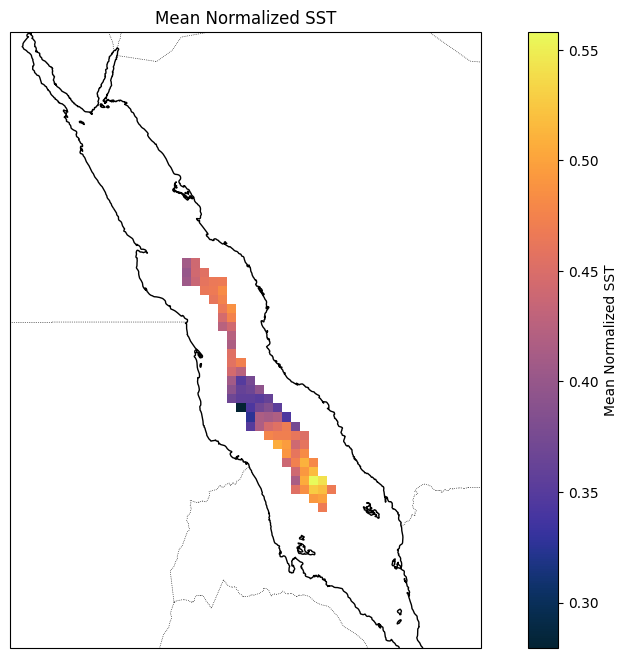

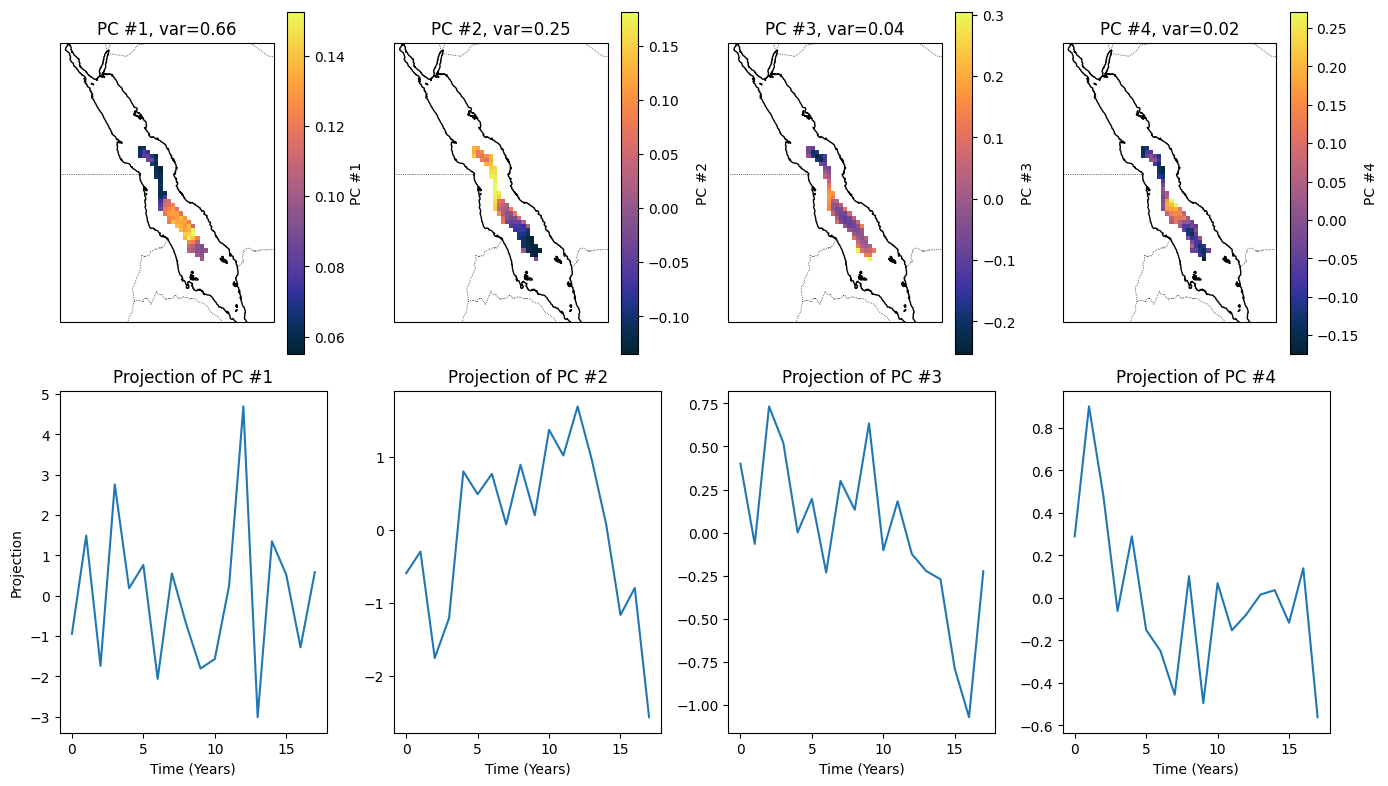

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import decomposition
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Assuming data is already loaded into `data`
print(len(np.unique(data['lon'])))
print(len(np.unique(data['lat'])))
print(len(np.unique(data['year'])))

# Initialize the 3D array (year, lon, lat)
A = np.ones((len(np.unique(data['year'])), len(np.unique(data['lon'])), len(np.unique(data['lat'])))) * np.nan

# Populate the array with data
for i1, i in enumerate(np.unique(data['lon'])):
    for j1, j in enumerate(np.unique(data['lat'])):
        for k1, k in enumerate(np.unique(data['year'])):
            x = np.where((data['lon'] == i) & (data['lat'] == j) & (data['year'] == k))[0]
            if len(x) > 0:
                A[k1, i1, j1] = data['mean_sst'][x[0]]

# Prepare PCA input
A2 = np.sum(A, axis=0)
i, j = np.where(A2 == A2)
indNoNaN = np.where(A2 == A2)
PCA_Matrix = A[:, i, j]

# Normalize the PCA matrix
PCA_Matrix_scaled = (PCA_Matrix - np.min(PCA_Matrix, axis=0)) / (np.max(PCA_Matrix, axis=0) - np.min(PCA_Matrix, axis=0))

# Apply PCA
NbPCA = 4
pca = decomposition.PCA(NbPCA)
pca.fit(PCA_Matrix_scaled)

# Initialize the Principal Component (PC) images
PC = np.zeros((NbPCA + 1, A.shape[1], A.shape[2])) * np.nan
PC[1:NbPCA + 1, indNoNaN[0], indNoNaN[1]] = pca.components_
PC[0, indNoNaN[0], indNoNaN[1]] = pca.mean_

# Visualize the Mean Normalized SST with Cartopy
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and borders
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Set the map extent (adjust according to your data region)
ax.set_extent([32, 45, 13, 30], crs=ccrs.PlateCarree())  # Adjust as per your data region

# Plot the Mean Component
imgplot = ax.pcolormesh(
    np.unique(data['lon']),
    np.unique(data['lat']),
    PC[0, :, :].T,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.thermal
)

# Add a color bar
plt.colorbar(imgplot, ax=ax, orientation='vertical', label='Mean Normalized SST')

# Add title and labels
plt.title('Mean Normalized SST')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Display the plot
plt.show()

# Visualize Principal Components and Projections
plt.figure(figsize=(14, 8))

for kk in range(NbPCA):
    # Principal Component as a spatial map
    ax = plt.subplot(2, NbPCA, kk + 1, projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.set_extent([32, 45, 13, 30], crs=ccrs.PlateCarree())

    imgplot = ax.pcolormesh(
        np.unique(data['lon']),
        np.unique(data['lat']),
        PC[kk + 1, :, :].T,
        transform=ccrs.PlateCarree(),
        cmap=cmocean.cm.thermal
    )
    plt.colorbar(imgplot, ax=ax, orientation='vertical', label=f'PC #{kk + 1}')
    plt.title(f'PC #{kk + 1}, var={pca.explained_variance_ratio_[kk]:.2f}')

    # Projection of the Principal Component
    plt.subplot(2, NbPCA, NbPCA + kk + 1)
    plt.plot(pca.transform(PCA_Matrix_scaled)[:, kk])
    plt.title(f'Projection of PC #{kk + 1}')
    plt.xlabel('Time (Years)')
    if kk == 0:
        plt.ylabel('Projection')

plt.tight_layout()
plt.show()


Text(0, 0.5, 'Explained variance')

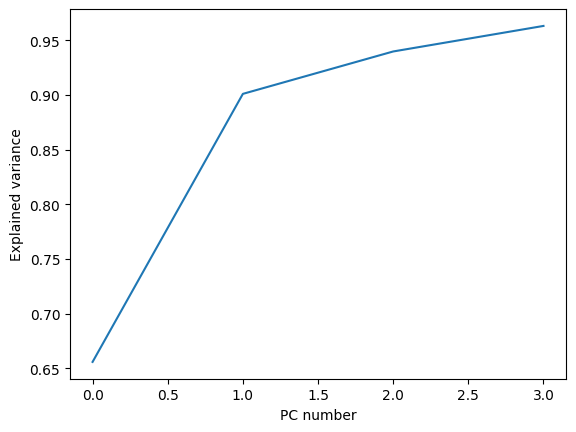

In [ ]:
# visualize PCA fit (explained variance)
plt.figure()
imgplot = plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('PC number')
plt.ylabel('Explained variance')

For SSH

17
28
18


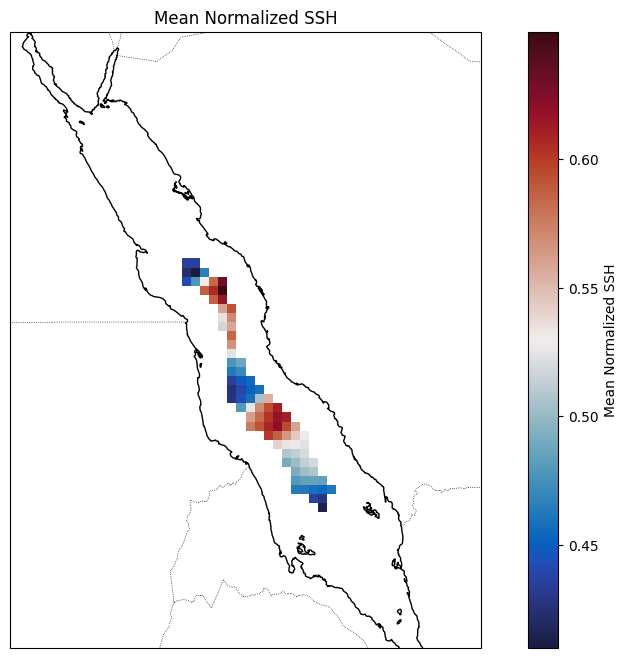

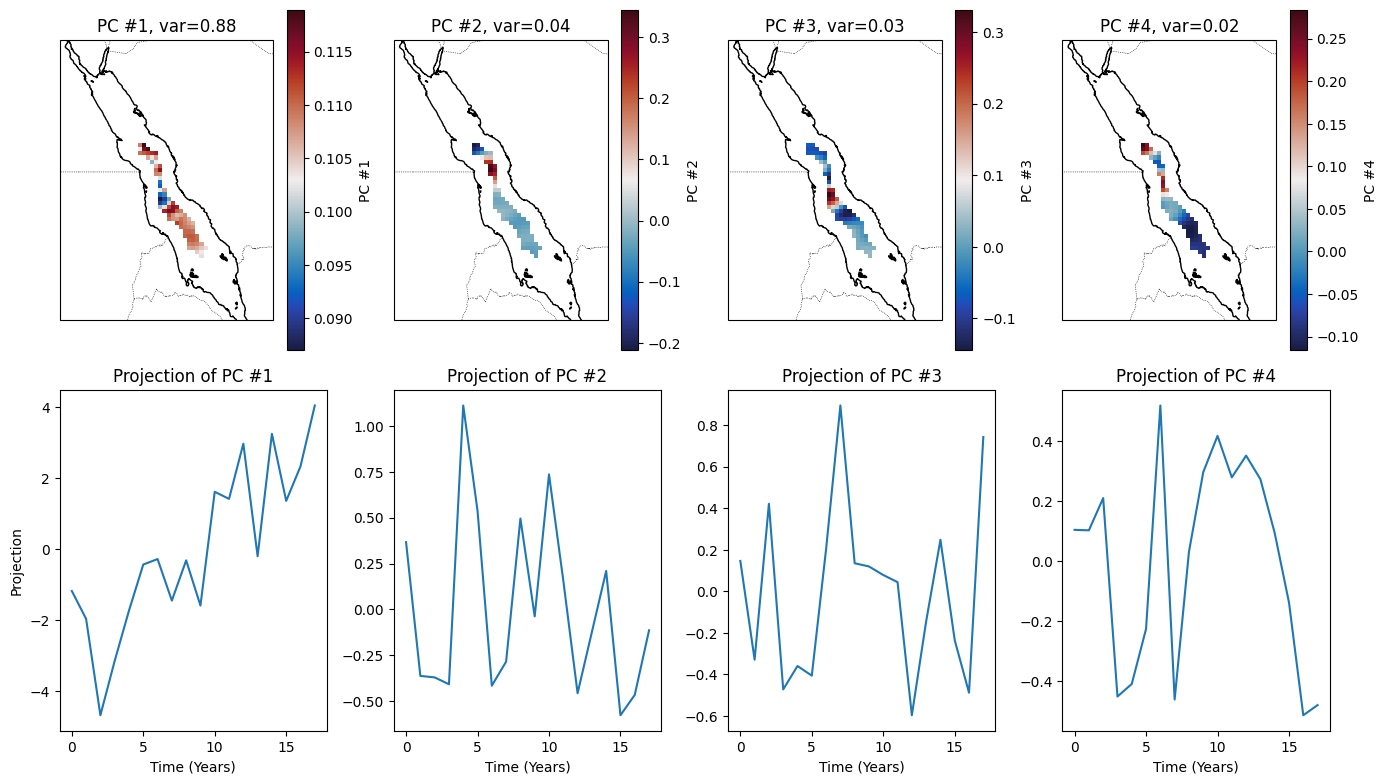

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import decomposition
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Assuming data is already loaded into `data`
print(len(np.unique(data['lon'])))
print(len(np.unique(data['lat'])))
print(len(np.unique(data['year'])))

# Initialize the 3D array (year, lon, lat)
A = np.ones((len(np.unique(data['year'])), len(np.unique(data['lon'])), len(np.unique(data['lat'])))) * np.nan

# Populate the array with data
for i1, i in enumerate(np.unique(data['lon'])):
    for j1, j in enumerate(np.unique(data['lat'])):
        for k1, k in enumerate(np.unique(data['year'])):
            x = np.where((data['lon'] == i) & (data['lat'] == j) & (data['year'] == k))[0]
            if len(x) > 0:
                A[k1, i1, j1] = data['mean_ssh'][x[0]]

# Prepare PCA input
A2 = np.sum(A, axis=0)
i, j = np.where(A2 == A2)
indNoNaN = np.where(A2 == A2)
PCA_Matrix = A[:, i, j]

# Normalize the PCA matrix
PCA_Matrix_scaled = (PCA_Matrix - np.min(PCA_Matrix, axis=0)) / (np.max(PCA_Matrix, axis=0) - np.min(PCA_Matrix, axis=0))

# Apply PCA
NbPCA = 4
pca = decomposition.PCA(NbPCA)
pca.fit(PCA_Matrix_scaled)

# Initialize the Principal Component (PC) images
PC = np.zeros((NbPCA + 1, A.shape[1], A.shape[2])) * np.nan
PC[1:NbPCA + 1, indNoNaN[0], indNoNaN[1]] = pca.components_
PC[0, indNoNaN[0], indNoNaN[1]] = pca.mean_

# Visualize the Mean Normalized SST with Cartopy
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and borders
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Set the map extent (adjust according to your data region)
ax.set_extent([32, 45, 13, 30], crs=ccrs.PlateCarree())  # Adjust as per your data region

# Plot the Mean Component
imgplot = ax.pcolormesh(
    np.unique(data['lon']),
    np.unique(data['lat']),
    PC[0, :, :].T,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.balance
)

# Add a color bar
plt.colorbar(imgplot, ax=ax, orientation='vertical', label='Mean Normalized SSH')

# Add title and labels
plt.title('Mean Normalized SSH')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Display the plot
plt.show()

# Visualize Principal Components and Projections
plt.figure(figsize=(14, 8))

for kk in range(NbPCA):
    # Principal Component as a spatial map
    ax = plt.subplot(2, NbPCA, kk + 1, projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.set_extent([32, 45, 13, 30], crs=ccrs.PlateCarree())

    imgplot = ax.pcolormesh(
        np.unique(data['lon']),
        np.unique(data['lat']),
        PC[kk + 1, :, :].T,
        transform=ccrs.PlateCarree(),
        cmap=cmocean.cm.balance
    )
    plt.colorbar(imgplot, ax=ax, orientation='vertical', label=f'PC #{kk + 1}')
    plt.title(f'PC #{kk + 1}, var={pca.explained_variance_ratio_[kk]:.2f}')

    # Projection of the Principal Component
    plt.subplot(2, NbPCA, NbPCA + kk + 1)
    plt.plot(pca.transform(PCA_Matrix_scaled)[:, kk])
    plt.title(f'Projection of PC #{kk + 1}')
    plt.xlabel('Time (Years)')
    if kk == 0:
        plt.ylabel('Projection')

plt.tight_layout()
plt.show()


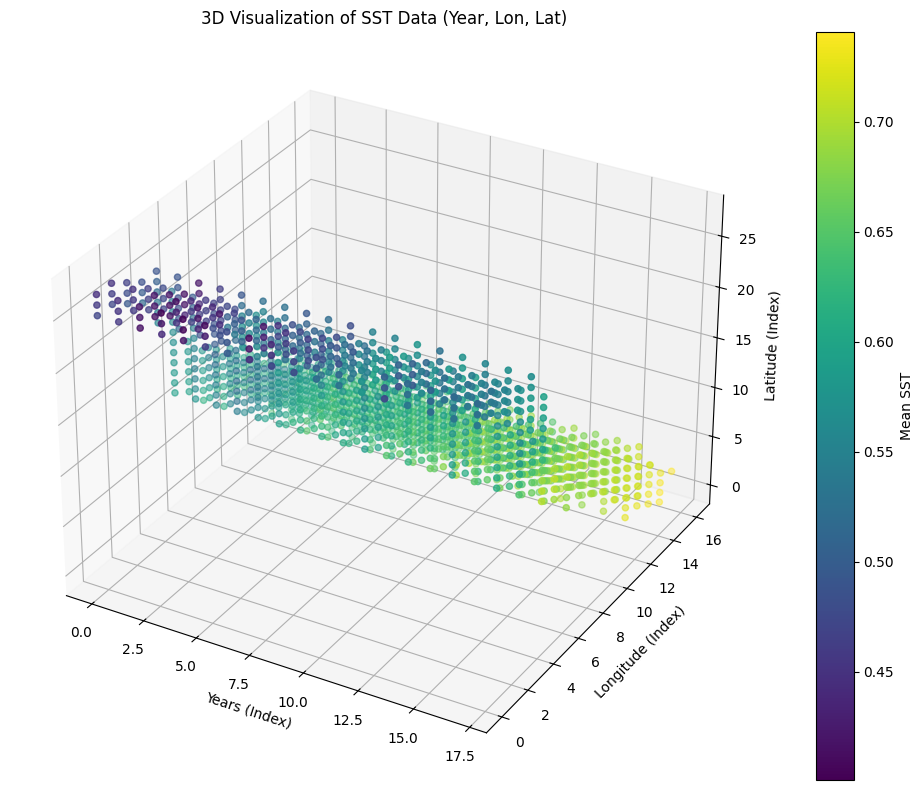

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
#%matplotlib qt

# Assuming your matrix `A` is already created and populated

# Create grids for years, latitudes, and longitudes
years = np.arange(A.shape[0])  # Indices for years
lons = np.arange(A.shape[1])  # Indices for longitudes
lats = np.arange(A.shape[2])  # Indices for latitudes

# Create 3D grid
years_grid, lons_grid, lats_grid = np.meshgrid(years, lons, lats, indexing="ij")

# Flatten the grid and data matrix for plotting
x = years_grid.flatten()
y = lons_grid.flatten()
z = lats_grid.flatten()
values = A.flatten()

# Filter out NaN values
valid = ~np.isnan(values)
x, y, z, values = x[valid], y[valid], z[valid], values[valid]

# Create 3D scatter plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(x, y, z, c=values, cmap="viridis", marker='o')

# Add colorbar
cbar = plt.colorbar(sc, ax=ax, label="Mean SST")

# Label axes
ax.set_xlabel("Years (Index)")
ax.set_ylabel("Longitude (Index)")
ax.set_zlabel("Latitude (Index)")

# Title and layout
plt.title("3D Visualization of SST Data (Year, Lon, Lat)")
plt.tight_layout()

# Display the plot
plt.show()
